In [12]:
import pandas as pd
import pymysql

connection = pymysql.connect(
    host='95.131.149.21',
    user='mgpu_ico_etl_05',
    password='Password',
    database='mgpu_ico_etl_05'
)

query = "SELECT * FROM service_quality_report"

df = pd.read_sql(query, connection)

df.head()

/tmp/ipykernel_5364/60305940.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,order_id,customer_id,rating,delivery_minutes
0,258,3507,3,11694
1,1877,9897,3,13804
2,2407,6111,5,8271
3,2407,6111,3,8271
4,2662,250,5,2245


In [13]:
df = df.dropna()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['delivery_minutes']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("R2:", model.score(X_test, y_test))

R2: -0.001946379607057347


In [15]:
df['service_quality'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df[['delivery_minutes']]
y = df['service_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       176
           1       0.65      1.00      0.79       332

    accuracy                           0.65       508
   macro avg       0.33      0.50      0.40       508
weighted avg       0.43      0.65      0.52       508



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


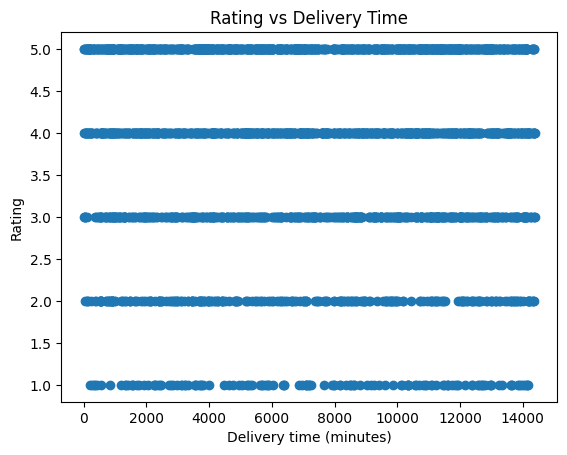

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['delivery_minutes'], df['rating'])
plt.xlabel('Delivery time (minutes)')
plt.ylabel('Rating')
plt.title('Rating vs Delivery Time')

plt.show()